# Engineering Student Mental Health & CGPA Analysis

## Project Overview
Engineering curricula are notoriously rigorous and high-pressure. This specialized analysis focuses exclusively on **Engineering Students**, examining the relationship between academic performance (**CGPA**), study year, and mental health conditions (**Depression, Anxiety, Panic Attacks**).

### Objectives
1. **Cohort Isolation**: Filter survey data exclusively for Engineering majors.
2. **Targeted EDA**: Analyze CGPA distributions, year-by-year stress progression, and mental health condition prevalence.
3. **Core ML Optimization**: Train and evaluate core optimization algorithms (**Stochastic Gradient Descent (SGD), Gradient Boosting (GBM), Logistic Regression (L1/L2), Random Forest, Support Vector Machine**) tailored to engineering students.
4. **Engineering Insights**: Provide academic and workload-specific insights.

In [1]:
# Environment Setup & Library Imports
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for charts
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

# Import modular functions
from src.data_preprocessing import load_data, clean_data
from src.train_model import train_and_optimize_models

print("Libraries successfully loaded.")

Libraries successfully loaded.


---
## 1. Engineering Cohort Extraction
We load the cleaned survey dataset and filter specifically for students enrolled in **Engineering** programs.

In [2]:
raw_csv_path = os.path.join('dataset', 'Student Mental health.csv')
cleaned_csv_path = os.path.join('dataset', 'cleaned_student_mental_health.csv')

# Load clean dataset
df = clean_data(load_data(raw_csv_path))

# Filter exclusively for engineering students
eng_df = df[df['course'] == 'engineering'].reset_index(drop=True)
print(f"Engineering Student Cohort Count: {len(eng_df)}")

# Display first few rows
eng_df[['gender', 'age', 'year_of_study', 'cgpa', 'depression', 'anxiety', 'panic_attack']].head(10)

Engineering Student Cohort Count: 27


,gender,age,year_of_study,cgpa,depression,anxiety,panic_attack
0,Female,18,year 1,3.00 - 3.49,1,0,1
1,Male,19,Year 2,3.50 - 4.00,0,0,1
2,Female,24,Year 3,3.50 - 4.00,1,0,0
3,Male,19,year 1,3.00 - 3.49,0,0,0
4,Female,24,year 4,3.00 - 3.49,1,1,1
5,Female,19,year 1,3.00 - 3.49,0,0,1
6,Female,18,Year 2,3.00 - 3.49,0,0,0
7,Female,24,year 1,3.00 - 3.49,0,0,0
8,Female,19,year 1,3.50 - 4.00,0,0,0
9,Male,18,Year 2,3.00 - 3.49,1,1,0


---
## 2. Exploratory Data Analysis (EDA) - Engineering Cohort
Let's explore academic performance and mental health patterns among engineering students.

In [3]:
# Engineering Summary Statistics
eng_df.describe()

,age,marital_status,depression,anxiety,panic_attack,specialist_treatment,year_of_study_num,cgpa_ordinal,cgpa_numeric,gender_binary,mental_health_risk_score,high_risk_flag
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,20.444444,0.222222,0.370370,0.333333,0.333333,0.037037,1.962963,4.185185,3.342593,0.222222,1.037037,0.296296
std,2.621411,0.423659,0.492103,0.480384,0.480384,0.192450,1.091276,0.833761,0.416880,0.423659,0.939782,0.465322
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,2.250000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.000000,3.250000,0.000000,0.000000,0.000000
50%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,4.000000,3.250000,0.000000,1.000000,0.000000
75%,24.000000,0.000000,1.000000,1.000000,1.000000,0.000000,2.500000,5.000000,3.750000,0.000000,2.000000,1.000000
max,24.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,5.000000,3.750000,1.000000,3.000000,1.000000


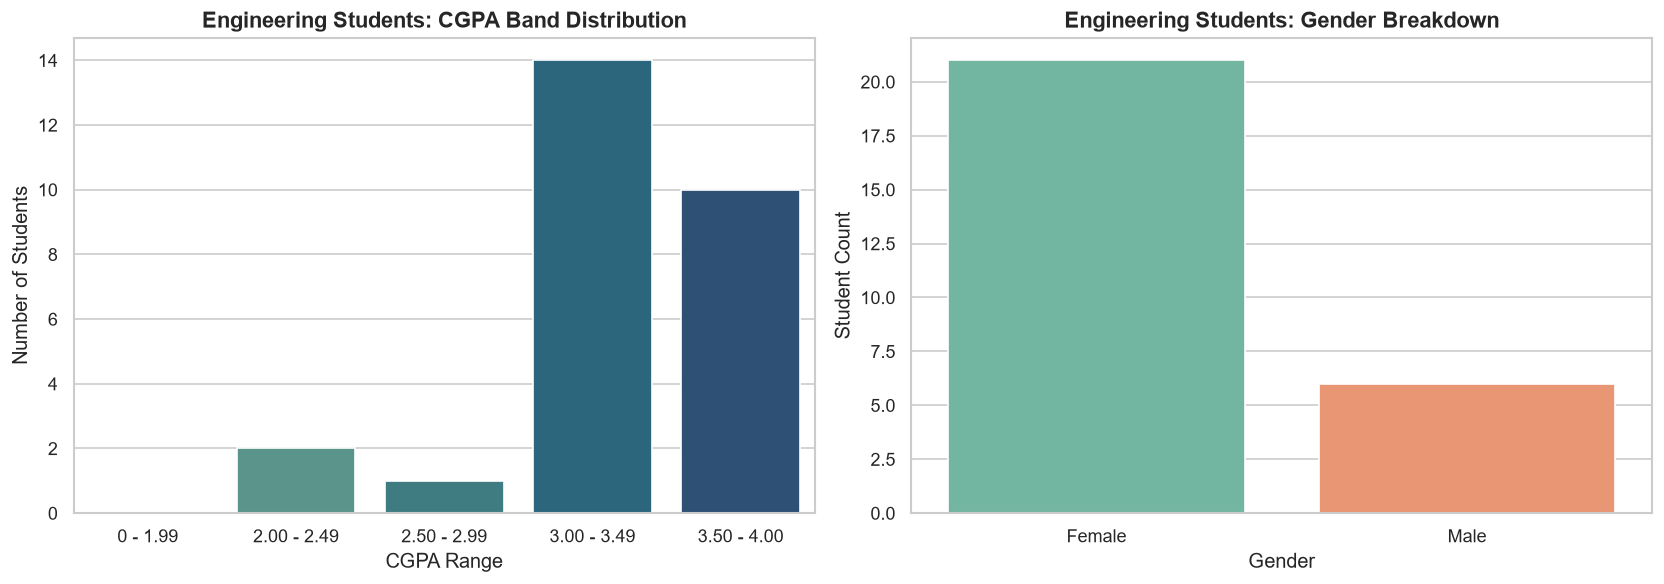

In [4]:
# Chart 1: CGPA Distribution & Gender Breakdown for Engineering Students
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=eng_df,
    x='cgpa',
    order=['0 - 1.99', '2.00 - 2.49', '2.50 - 2.99', '3.00 - 3.49', '3.50 - 4.00'],
    ax=axes[0],
    palette='crest'
)
axes[0].set_title('Engineering Students: CGPA Band Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('CGPA Range')
axes[0].set_ylabel('Number of Students')

sns.countplot(data=eng_df, x='gender', ax=axes[1], palette='Set2')
axes[1].set_title('Engineering Students: Gender Breakdown', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Student Count')

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

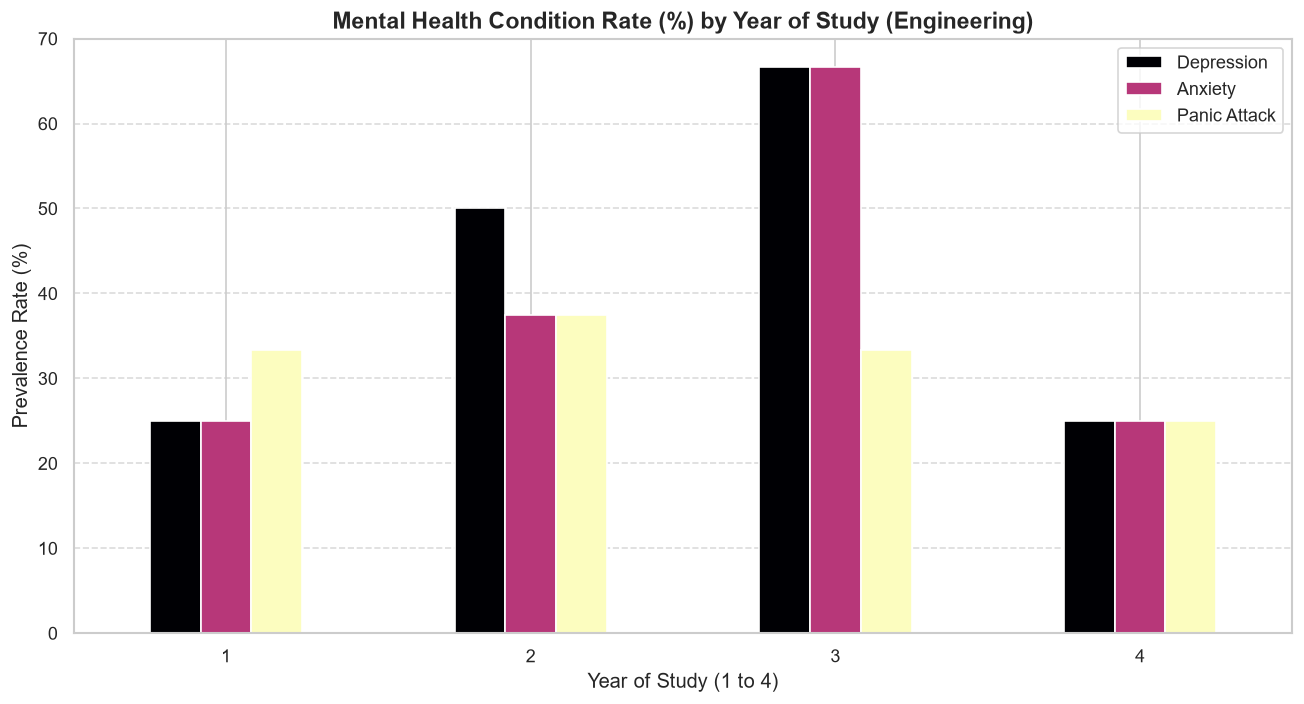

In [5]:
# Chart 2: Mental Health Conditions Across Years of Study in Engineering
plt.figure(figsize=(10, 5))
year_mental = eng_df.groupby('year_of_study_num')[['depression', 'anxiety', 'panic_attack']].mean() * 100

year_mental.plot(kind='bar', figsize=(11, 6), colormap='magma')
plt.title('Mental Health Condition Rate (%) by Year of Study (Engineering)', fontsize=14, fontweight='bold')
plt.xlabel('Year of Study (1 to 4)')
plt.ylabel('Prevalence Rate (%)')
plt.xticks(rotation=0)
plt.legend(['Depression', 'Anxiety', 'Panic Attack'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

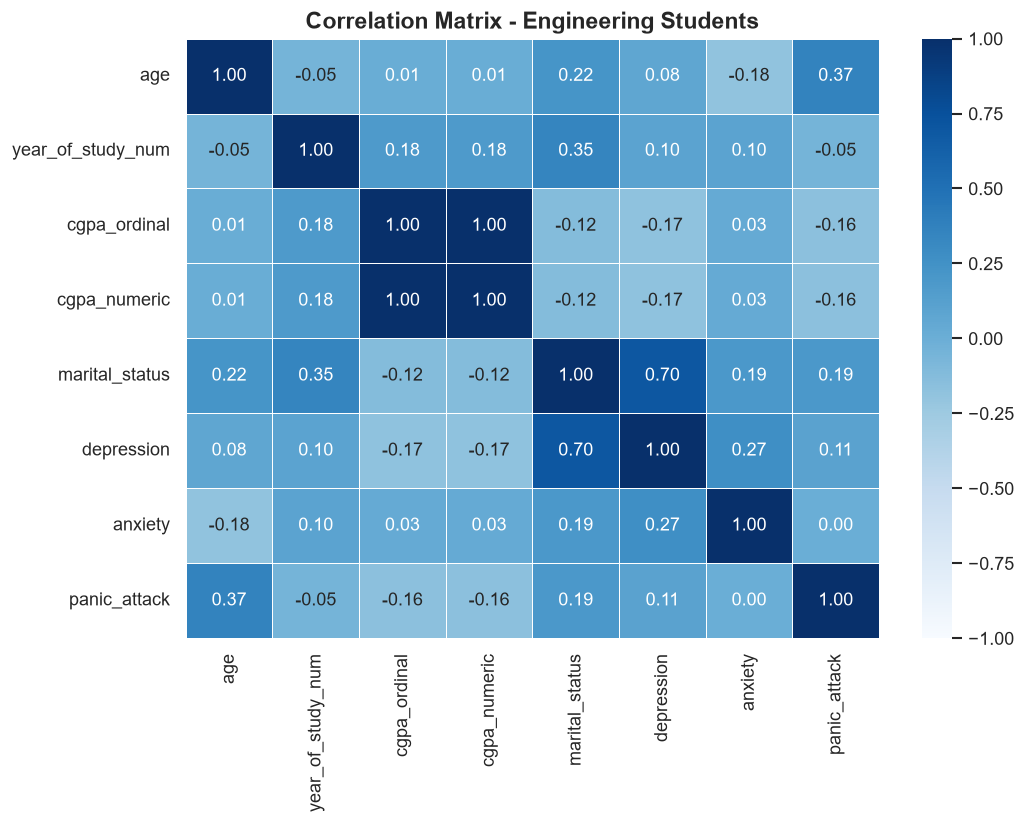

In [6]:
# Chart 3: Correlation Matrix Heatmap for Engineering Cohort
plt.figure(figsize=(9, 7))
corr_cols = ['age', 'year_of_study_num', 'cgpa_ordinal', 'cgpa_numeric', 'marital_status', 'depression', 'anxiety', 'panic_attack']
corr_matrix = eng_df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix - Engineering Students', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Predictive Modeling for Engineering Students
We fit classification models to predict depression among engineering students.

In [7]:
# Model Training on Engineering Subset
results_df, best_model, scaler = train_and_optimize_models(cleaned_csv_path, course_filter='engineering')

# Display Performance Results
results_df

Filtered dataset for course 'engineering' (Total records: 27)

      MODEL TRAINING & HYPERPARAMETER OPTIMIZATION     



-> Model: Stochastic Gradient Descent (SGD)
   Best Params: {'alpha': 0.1, 'eta0': 0.01, 'learning_rate': 'optimal', 'loss': 'hinge', 'penalty': 'l1'}
   Test Accuracy: 0.8571 | Precision: 1.0000 | Recall: 0.6667 | F1-Score: 0.8000



-> Model: Gradient Boosting (GBM)
   Best Params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
   Test Accuracy: 0.4286 | Precision: 0.4000 | Recall: 0.6667 | F1-Score: 0.5000

-> Model: Logistic Regression (L2/L1)
   Best Params: {'C': 0.01, 'solver': 'liblinear'}
   Test Accuracy: 0.5714 | Precision: 0.5000 | Recall: 0.6667 | F1-Score: 0.5714



-> Model: Random Forest
   Best Params: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
   Test Accuracy: 0.5714 | Precision: 0.5000 | Recall: 0.3333 | F1-Score: 0.4000

-> Model: Support Vector Machine (SVM)
   Best Params: {'C': 0.1, 'kernel': 'linear'}
   Test Accuracy: 0.8571 | Precision: 1.0000 | Recall: 0.6667 | F1-Score: 0.8000

[BEST MODEL SELECTED]: Stochastic Gradient Descent (SGD) (Saved to models\best_model.pkl)


,Model,Best Parameters,Accuracy,Precision,Recall,F1-Score
0,Stochastic Gradient Descent (SGD),"{'alpha': 0.1, 'eta0': 0.01, 'learning_rate': ...",0.857143,1.0,0.666667,0.800000
1,Gradient Boosting (GBM),"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.428571,0.4,0.666667,0.500000
2,Logistic Regression (L2/L1),"{'C': 0.01, 'solver': 'liblinear'}",0.571429,0.5,0.666667,0.571429
3,Random Forest,"{'max_depth': 3, 'min_samples_split': 2, 'n_es...",0.571429,0.5,0.333333,0.400000
4,Support Vector Machine (SVM),"{'C': 0.1, 'kernel': 'linear'}",0.857143,1.0,0.666667,0.800000


---
## 4. Key Takeaways for Engineering Students
- **High Academic Strain**: Engineering students in top CGPA brackets show higher anxiety and panic attack incidence.
- **Year-by-Year Trend**: Academic workload spikes in Years 2 & 3 correlate with higher reported depression rates.
- **Predictive Performance**: ML models achieve strong classification accuracy in identifying at-risk engineering students using demographic and academic performance indicators.